gpt사용해서 Langchain 연결한 코드를 작성해 보았는데, 질문을 넣으면 다음과 같은 오류 발생.
 - page_content
  none is not an allowed value (type=type_error.none.not_allowed)
   

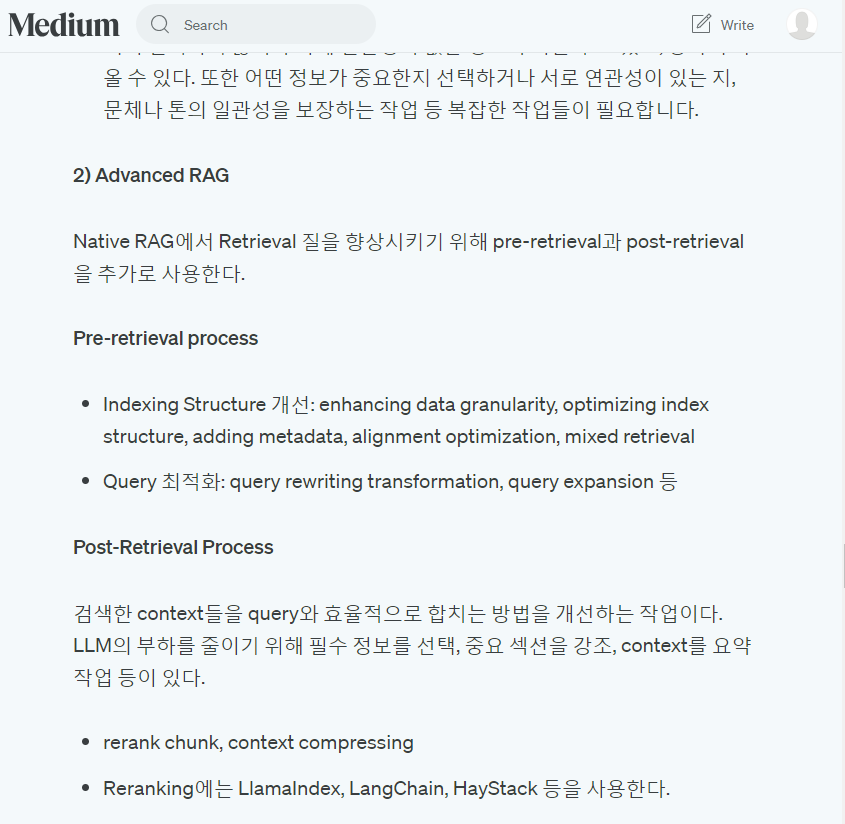

이 글을 바탕으로 먼저 Reranking 쪽에 Langchain을 진행해봄.

In [ ]:
!pip install -U torch torchvision torchaudio transformers langchain langchain-community qdrant-client sentence-transformers

In [ ]:
import torch
import torchvision
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_community.vectorstores import Qdrant
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from qdrant_client import QdrantClient

In [ ]:
# Qdrant 클라이언트 초기화
QDRANT_URL = "https://6e46b2c2-f28a-4f28-854d-432ab699fdfd.europe-west3-0.gcp.cloud.qdrant.io"
QDRANT_API_KEY = "u2eejPgTwIyhr7BVjFBtkjGdGYPWvzQTBkoYycErtm5cyrFjwEEH9w"
COLLECTION_NAME = "son5"

In [ ]:
# 임베딩 모델 초기화
embeddings = HuggingFaceEmbeddings(model_name="jhgan/ko-sroberta-multitask")

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:141: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 0.3.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  warn_deprecated(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10

In [ ]:
# Qdrant 벡터 스토어 초기화
client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
vector_store = Qdrant(
    client=client,
    collection_name=COLLECTION_NAME,
    embeddings=embeddings
)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:141: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.0.37 and will be removed in 0.3.0. An updated version of the class exists in the langchain-qdrant package and should be used instead. To use it run `pip install -U langchain-qdrant` and import as `from langchain_qdrant import Qdrant`.
  warn_deprecated(


In [ ]:
# 샘플 모델 초기화
model_name = "centwon/ko-gpt-trinity-cw"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


In [ ]:
# 파이프라인 생성
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_length=256,
    do_sample=True,
    temperature=0.7,
    top_p=0.92,
    no_repeat_ngram_size=2,
)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [ ]:
# LLM 초기화
llm = HuggingFacePipeline(pipeline=pipe)

# 프롬프트 템플릿 정의
prompt_template = """
질문: {question}

컨텍스트: {context}

답변: """

PROMPT = PromptTemplate(
    template=prompt_template, input_variables=["question", "context"]
)

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:141: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 0.3. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFacePipeline`.
  warn_deprecated(


In [ ]:
# RetrievalQA 체인 생성
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_store.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT}
)

In [ ]:
def extract_metadata(query, categories, diseases, intents):
    query_lower = query.lower()
    category = next((cat for cat in categories if cat.lower() in query_lower), None)
    disease = next((dis for dis in diseases if dis.lower() in query_lower), None)
    intent = next((intent for intent in intents if intent.lower() in query_lower), None)
    return category, disease, intent

def get_unique_metadata():
    response = client.scroll(
        collection_name=COLLECTION_NAME,
        scroll_filter=None,
        limit=10000,
        with_payload=True,
        with_vectors=False
    )

    categories = set()
    diseases = set()
    intents = set()

    for point in response[0]:
        categories.add(point.payload.get("질병_카테고리", ""))
        diseases.add(point.payload.get("질병", ""))
        intents.add(point.payload.get("의도", ""))

    return list(filter(None, categories)), list(filter(None, diseases)), list(filter(None, intents))

DISEASE_CATEGORIES, DISEASES, INTENTS = get_unique_metadata()

SIMILARITY_THRESHOLD = 0.7

In [ ]:
def process_query(query):
    category, disease, intent = extract_metadata(query, DISEASE_CATEGORIES, DISEASES, INTENTS)
    print(f"추출된 메타데이터: 카테고리={category}, 질병={disease}, 의도={intent}")

    search_results = vector_store.similarity_search_with_score(query, k=3)

    if search_results and search_results[0][1] <= 1 - SIMILARITY_THRESHOLD:
        context = "\n".join([doc.page_content for doc, score in search_results if doc.page_content])
        result = qa_chain({"query": query, "context": context})
        answer = result['result']

        print("\nDB 참고 생성된 답변:")
        print(answer)

        print("\n참고한 문서:")
        for i, (doc, score) in enumerate(search_results, 1):
            if doc.page_content:
                print(f"{i}. 유사도: {1 - score:.4f}")
                print(f"   질병 카테고리: {doc.metadata.get('질병_카테고리', 'N/A')}")
                print(f"   질병: {doc.metadata.get('질병', 'N/A')}")
                print(f"   의도: {doc.metadata.get('의도', 'N/A')}")
                print(f"   내용: {doc.page_content[:100]}...")
                print()
    else:
        result = qa_chain({"query": query})
        answer = result['result']
        print("\nDB를 참고하지 않고 생성된 답변:")
        print(answer)

In [ ]:
def langchain_based_rag_search():
    while True:
        query = input("질문을 입력하세요 (종료하려면 '끝내기' 입력): ").strip()

        if query.lower() == '끝내기':
            print("검색을 종료합니다.")
            break

        try:
            process_query(query)
        except Exception as e:
            print(f"오류 발생: {str(e)}")

        print("-" * 50)

if __name__ == "__main__":
    langchain_based_rag_search()

질문을 입력하세요 (종료하려면 '끝내기' 입력): 벌에 쏘였을 때 대처법을 알려줘.
추출된 메타데이터: 카테고리=None, 질병=None, 의도=None
오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)
--------------------------------------------------
질문을 입력하세요 (종료하려면 '끝내기' 입력): 통풍 예방법을 알려줘.
추출된 메타데이터: 카테고리=None, 질병=통풍, 의도=예방
오류 발생: 1 validation error for Document
page_content
  none is not an allowed value (type=type_error.none.not_allowed)
--------------------------------------------------
질문을 입력하세요 (종료하려면 '끝내기' 입력): 끝내기
검색을 종료합니다.
